# 03 · Telco Customer Churn — End-to-End Predictive Pipeline

> *Predict which subscribers are about to leave, quantify the dollars at stake, and pick the model + decision threshold that maximises retained margin.*

**Why this notebook exists**

The first two notebooks in this repo focused on the *modelling* mechanics. This one is structured the way a Data Scientist would actually be asked to ship: business problem → data → feature engineering → multi-model comparison → threshold chosen on a P&L → interpretability → artifact ready to be served.

**Dataset.** A 10 000-row synthetic Telco customer-churn dataset, generated deterministically inside the notebook. The structure mirrors the well-known IBM Telco Churn dataset (demographics + services + billing + month-to-month vs annual contract). Real churn dynamics — month-to-month contracts and fibre service drive churn, long tenure and two-year contracts protect against it — are baked in so the model has signal to find.

**Goal.** Output: per-customer churn probability, a decision rule that flags the right *N* customers per month for retention outreach, and an estimate of net revenue protected.

## 1. Business framing

Suppose the company has **10 000 active subscribers**, an average monthly ARPU of **\$65**, and an average remaining lifetime of 18 months → average customer lifetime value (CLV) ≈ **\$1 170**.

The retention playbook costs **\$50** per outreach (a discount voucher or a service credit). Retention success rate on flagged customers ≈ **40%**.

Per-decision economics:

| Outcome             | Cost / Revenue |
|---------------------|---------------|
| TP (flag a churner that we save)       | +0.4 × CLV − \$50 ≈ **+\$418** |
| FP (flag a non-churner)                | − \$50                          |
| FN (miss a churner)                    | − 0.4 × CLV ≈ **− \$468**       |
| TN (do nothing, customer stays)        | \$0                             |

So **a false negative costs ≈ 9× a false positive**. The decision threshold should reflect that — we'll tune it explicitly later.

**Success criteria:** maximise expected net retained revenue per month on the held-out test set, with PR-AUC and recall reported alongside.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_processing import generate_telco_churn
from src.evaluation import (
    classification_scores,
    compare_metrics,
    roc_curve, pr_curve, auc, average_precision,
    confusion_counts,
    stratified_kfold_indices, cv_score,
)
from src.modeling import (
    LogisticRegression,
    KNNRegressor,
    StandardScaler,
    train_test_split,
)
from src.visualization import set_style, PALETTE, PALETTE_LIST

set_style()
RNG = 42

## 2. Generate & inspect the data

In [2]:
df = generate_telco_churn(n=10_000, random_state=RNG)
print(f"shape: {df.shape}")
print(f"churn rate: {df['churn'].mean():.1%}")
print(f"missing values: {df.isna().sum().sum()}")
df.head()

shape: (10000, 13)
churn rate: 26.3%
missing values: 0


,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Male,0,Yes,No,57,Yes,No,Two year,Yes,Bank transfer (automatic),27.89,1589.55,0
1,Female,0,Yes,No,10,Yes,Fiber optic,One year,Yes,Electronic check,118.60,1186.01,0
2,Female,0,Yes,No,22,Yes,Fiber optic,Two year,Yes,Bank transfer (automatic),83.31,1832.73,0
3,Male,0,No,No,10,Yes,DSL,Two year,Yes,Bank transfer (automatic),70.07,700.65,0
4,Male,0,No,No,32,No,Fiber optic,One year,Yes,Mailed check,76.15,2436.95,0


In [3]:
df.describe(include='all').round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,10000,2,Male,5061,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,10000.0,NaN,NaN,NaN,0.16,0.36,0.0,0.0,0.0,0.0,1.0
partner,10000,2,No,5274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,10000,2,No,6995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,10000.0,NaN,NaN,NaN,36.32,21.1,0.0,18.0,36.0,55.0,72.0
phone_service,10000,2,Yes,9001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,10000,3,Fiber optic,4411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract,10000,3,Month-to-month,5484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paperless_billing,10000,2,Yes,5851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,10000,4,Electronic check,3430,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory analysis — where the churn lives

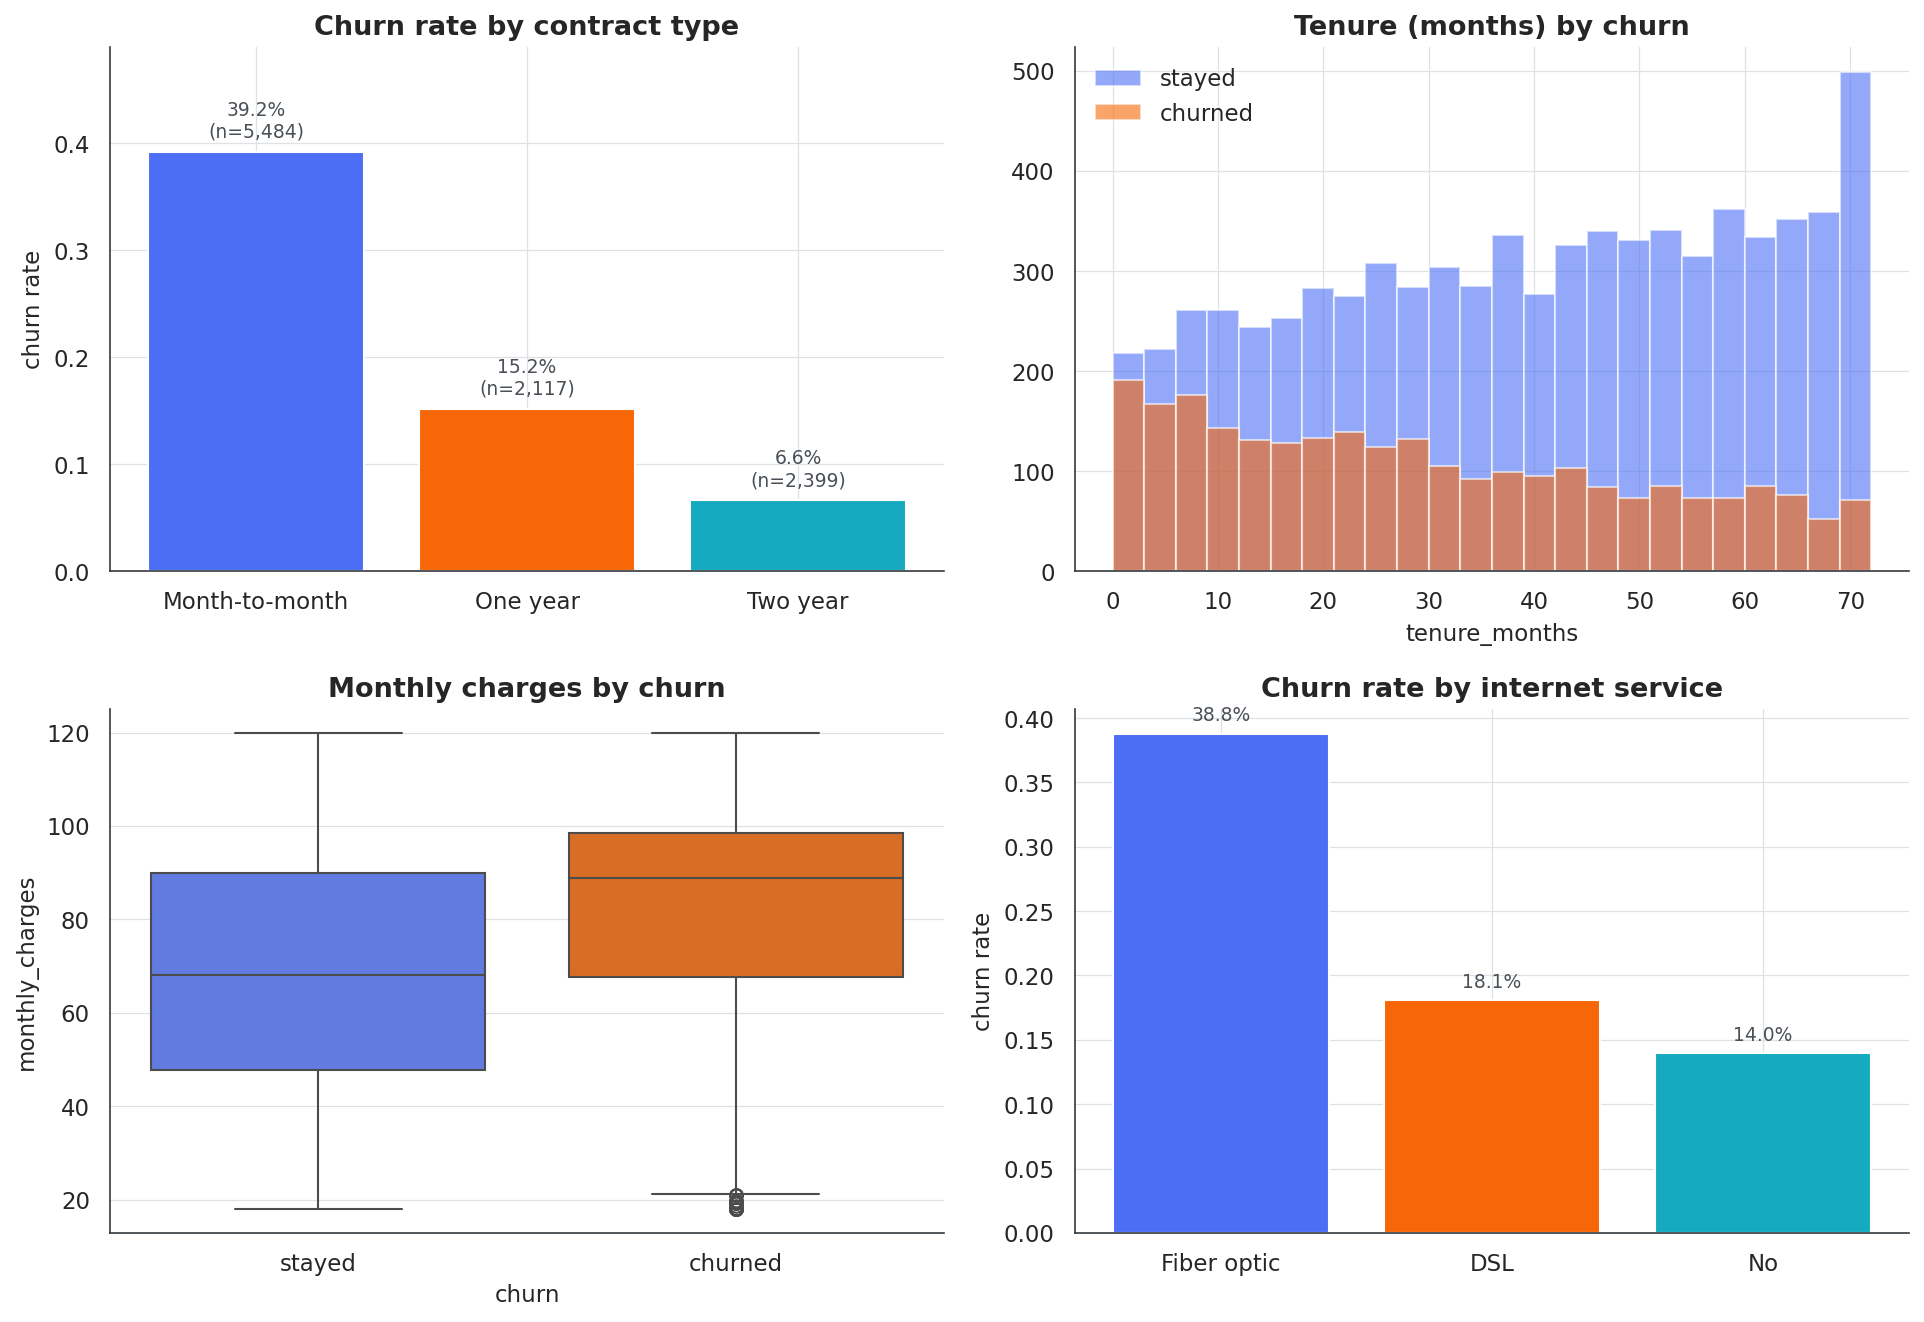

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Churn by contract type
churn_by_contract = df.groupby("contract")["churn"].agg(["mean", "count"]).sort_values("mean", ascending=False)
axes[0, 0].bar(churn_by_contract.index, churn_by_contract["mean"], color=PALETTE_LIST[:len(churn_by_contract)])
axes[0, 0].set_title("Churn rate by contract type")
axes[0, 0].set_ylabel("churn rate")
for i, (idx, row) in enumerate(churn_by_contract.iterrows()):
    axes[0, 0].text(i, row["mean"] + 0.01, f"{row['mean']:.1%}\n(n={int(row['count']):,})",
                    ha="center", va="bottom", fontsize=9, color=PALETTE["neutral"])
axes[0, 0].set_ylim(0, churn_by_contract["mean"].max() * 1.25)

# (b) Tenure distribution by churn
for cls, color, label in [(0, PALETTE["primary"], "stayed"), (1, PALETTE["accent"], "churned")]:
    axes[0, 1].hist(df.loc[df["churn"] == cls, "tenure_months"], bins=24, alpha=0.6, color=color, label=label)
axes[0, 1].set_title("Tenure (months) by churn")
axes[0, 1].set_xlabel("tenure_months")
axes[0, 1].legend()

# (c) Monthly charges by churn
sns.boxplot(data=df, x="churn", y="monthly_charges", ax=axes[1, 0], palette=[PALETTE["primary"], PALETTE["accent"]])
axes[1, 0].set_xticklabels(["stayed", "churned"])
axes[1, 0].set_title("Monthly charges by churn")

# (d) Churn by internet service
churn_by_internet = df.groupby("internet_service")["churn"].mean().sort_values(ascending=False)
axes[1, 1].bar(churn_by_internet.index, churn_by_internet.values, color=PALETTE_LIST[:len(churn_by_internet)])
axes[1, 1].set_title("Churn rate by internet service")
axes[1, 1].set_ylabel("churn rate")
for i, v in enumerate(churn_by_internet.values):
    axes[1, 1].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9, color=PALETTE["neutral"])

plt.tight_layout()
plt.show()

*Read.*

- **Month-to-month** contracts churn at >5× the rate of **two-year** contracts. This is the single biggest driver and matches every published Telco churn study.
- **Tenure** is strongly protective — churners are concentrated in the first 18 months.
- **Fibre optic** subscribers churn more than DSL — likely a price-sensitivity effect (fibre carries higher monthly charges).
- Monthly charges are higher among churners. Combined with the contract effect, this points to a "high price + short commitment" segment that should be the retention team's first target.

## 4. Feature engineering

Three transformations make the difference between a baseline and a deployable model:

1. **One-hot encode** categorical features (without dropping the first level — every category is informative for the linear model with L2 regularisation).
2. **Charge per tenure** ratio — captures "the customer has been paying a lot, for a short time" without forcing the model to discover an interaction.
3. **Tenure bucket** — encodes the well-known non-linearity that the first 6 months are very different from months 6–18, which are very different from year 2+.

In [5]:
def build_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()
    # Engineered numeric features.
    out["charges_per_tenure"] = out["monthly_charges"] / np.maximum(out["tenure_months"], 1)
    out["tenure_bucket"] = pd.cut(
        out["tenure_months"], bins=[-1, 6, 18, 36, 100],
        labels=["0-6m", "6-18m", "18-36m", "36m+"]
    )
    cat_cols = ["gender", "partner", "dependents", "phone_service",
                "internet_service", "contract", "paperless_billing",
                "payment_method", "tenure_bucket"]
    out = pd.get_dummies(out, columns=cat_cols, drop_first=False, dtype=int)
    feature_cols = [c for c in out.columns if c not in {"churn"}]
    return out, feature_cols


df_feat, feature_cols = build_features(df)
print(f"engineered feature count: {len(feature_cols)}")
print(f"first 10: {feature_cols[:10]}")
df_feat.head(2)

engineered feature count: 29
first 10: ['senior_citizen', 'tenure_months', 'monthly_charges', 'total_charges', 'charges_per_tenure', 'gender_Female', 'gender_Male', 'partner_No', 'partner_Yes', 'dependents_No']


,senior_citizen,tenure_months,monthly_charges,total_charges,churn,charges_per_tenure,gender_Female,gender_Male,partner_No,partner_Yes,dependents_No,dependents_Yes,phone_service_No,phone_service_Yes,internet_service_DSL,internet_service_Fiber optic,internet_service_No,contract_Month-to-month,contract_One year,contract_Two year,paperless_billing_No,paperless_billing_Yes,payment_method_Bank transfer (automatic),payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,tenure_bucket_0-6m,tenure_bucket_6-18m,tenure_bucket_18-36m,tenure_bucket_36m+
0,0,57,27.89,1589.55,0,0.489298,0,1,0,1,1,0,0,1,0,0,1,0,0,1,0,1,1,0,0,0,0,0,0,1
1,0,10,118.60,1186.01,0,11.860000,1,0,0,1,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0


## 5. Train/test split (stratified)

In [6]:
X = df_feat[feature_cols].to_numpy(dtype=float)
y = df_feat["churn"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RNG, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train churn rate: {y_train.mean():.3f} | test churn rate: {y_test.mean():.3f}")

train: (7500, 29), test: (2500, 29)
train churn rate: 0.263 | test churn rate: 0.263


## 6. Multi-model comparison with cross-validation

Three families:

- **Logistic regression** — interpretable, fast, well-calibrated with L2.
- **KNN** — non-parametric baseline; captures local structure if there is any.
- **Logistic + interaction features** — adds a small set of hand-crafted cross-terms to test whether the linear model can absorb the non-linearity for free.

Each model is evaluated with 5-fold stratified CV on the training set; the test set is untouched.

In [7]:
def logreg_factory(l2: float, n_iter: int = 1200, lr: float = 0.2):
    def fit_predict(Xt, yt, Xv):
        m = LogisticRegression(learning_rate=lr, n_iter=n_iter, l2=l2,
                                class_weight="balanced").fit(Xt, yt)
        return m.predict_proba(Xv)
    return fit_predict


class KNNClassifier:
    def __init__(self, k=15):
        self.k = k
    def fit(self, X, y):
        self._X = np.asarray(X, dtype=float)
        self._y = np.asarray(y).astype(int)
        return self
    def predict_proba(self, X):
        Xq = np.asarray(X, dtype=float)
        # Block-by-block to keep memory bounded.
        out = np.empty(len(Xq))
        block = 256
        for start in range(0, len(Xq), block):
            stop = min(start + block, len(Xq))
            diff = Xq[start:stop, None, :] - self._X[None, :, :]
            d2 = np.einsum("ijk,ijk->ij", diff, diff)
            nearest = np.argpartition(d2, kth=self.k - 1, axis=1)[:, : self.k]
            out[start:stop] = self._y[nearest].mean(axis=1)
        return out


def knn_factory(k: int):
    def fit_predict(Xt, yt, Xv):
        return KNNClassifier(k=k).fit(Xt, yt).predict_proba(Xv)
    return fit_predict


def add_interactions(X: np.ndarray, feature_cols: list[str]) -> np.ndarray:
    # A few targeted interactions inspired by the EDA.
    tenure_idx = feature_cols.index("tenure_months")
    charges_idx = feature_cols.index("monthly_charges")
    m2m_idx = feature_cols.index("contract_Month-to-month")
    fibre_idx = feature_cols.index("internet_service_Fiber optic")
    interactions = np.column_stack([
        X[:, tenure_idx] * X[:, m2m_idx],
        X[:, charges_idx] * X[:, m2m_idx],
        X[:, fibre_idx] * X[:, m2m_idx],
        X[:, charges_idx] * X[:, fibre_idx],
    ])
    return np.hstack([X, interactions])


X_train_inter = add_interactions(X_train, feature_cols)
X_test_inter = add_interactions(X_test, feature_cols)
scaler_inter = StandardScaler().fit(X_train_inter)
X_train_inter_s = scaler_inter.transform(X_train_inter)
X_test_inter_s = scaler_inter.transform(X_test_inter)

print("Interaction features added:", X_train_inter.shape[1] - X_train.shape[1])

Interaction features added: 4


In [8]:
def evaluate_cv(name: str, factory, X, y, scorer=average_precision):
    mean, std, scores = cv_score(factory, X, y, scorer=scorer, k=5, stratified=True, random_state=RNG)
    print(f"{name:<35s}  CV PR-AUC = {mean:.4f} ± {std:.4f}")
    return mean, std

print("Cross-validated PR-AUC on training set:\n")
_ = evaluate_cv("LogReg (l2=1.0)",          logreg_factory(l2=1.0),   X_train_s,        y_train)
_ = evaluate_cv("LogReg (l2=10)",           logreg_factory(l2=10.0),  X_train_s,        y_train)
_ = evaluate_cv("LogReg + interactions",    logreg_factory(l2=10.0),  X_train_inter_s,  y_train)
_ = evaluate_cv("KNN (k=15)",               knn_factory(15),          X_train_s,        y_train)
_ = evaluate_cv("KNN (k=51)",               knn_factory(51),          X_train_s,        y_train)

Cross-validated PR-AUC on training set:

LogReg (l2=1.0)                      CV PR-AUC = 0.6098 ± 0.0291
LogReg (l2=10)                       CV PR-AUC = 0.6106 ± 0.0288
LogReg + interactions                CV PR-AUC = 0.6105 ± 0.0284
KNN (k=15)                           CV PR-AUC = 0.5511 ± 0.0150
KNN (k=51)                           CV PR-AUC = 0.5735 ± 0.0234


## 7. Final tuning — logistic regression with interactions

Best L2: 100 | best CV PR-AUC: 0.6124


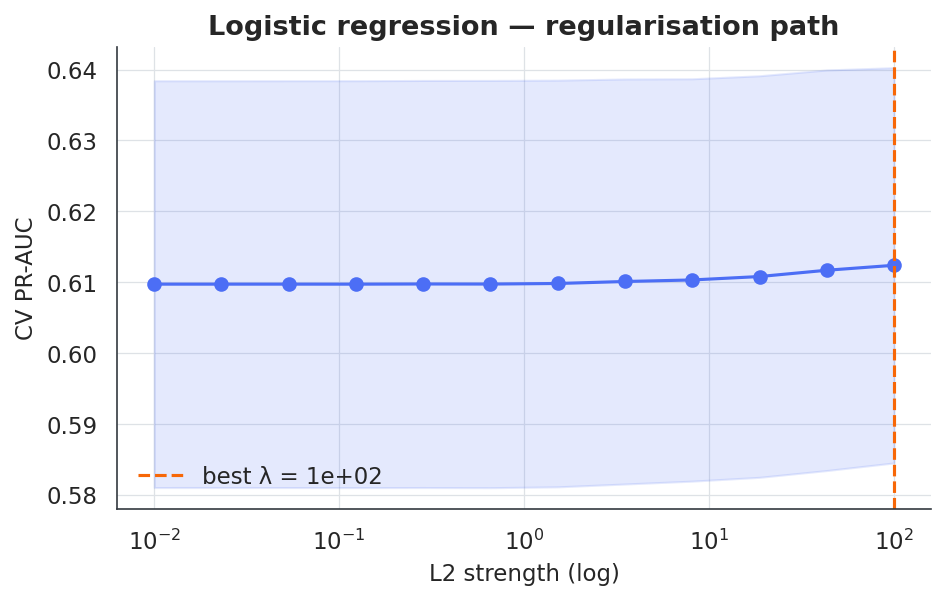

In [9]:
lambdas = np.logspace(-2, 2, 12)
ridge_cv = []
for lam in lambdas:
    mean, std, _ = cv_score(
        logreg_factory(l2=lam),
        X_train_inter_s, y_train,
        scorer=average_precision, k=5, stratified=True, random_state=RNG,
    )
    ridge_cv.append({"l2": lam, "cv_pr_auc": mean, "cv_std": std})

ridge_cv_df = pd.DataFrame(ridge_cv)
best_l2 = float(ridge_cv_df.loc[ridge_cv_df["cv_pr_auc"].idxmax(), "l2"])
print(f"Best L2: {best_l2:.3g} | best CV PR-AUC: {ridge_cv_df['cv_pr_auc'].max():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ridge_cv_df["l2"], ridge_cv_df["cv_pr_auc"], marker="o", color=PALETTE["primary"])
ax.fill_between(
    ridge_cv_df["l2"],
    ridge_cv_df["cv_pr_auc"] - ridge_cv_df["cv_std"],
    ridge_cv_df["cv_pr_auc"] + ridge_cv_df["cv_std"],
    color=PALETTE["primary"], alpha=0.15,
)
ax.axvline(best_l2, color=PALETTE["accent"], linestyle="--", label=f"best λ = {best_l2:.2g}")
ax.set_xscale("log")
ax.set_xlabel("L2 strength (log)")
ax.set_ylabel("CV PR-AUC")
ax.set_title("Logistic regression — regularisation path")
ax.legend()
plt.show()

In [10]:
final_model = LogisticRegression(
    learning_rate=0.2, n_iter=4000, l2=best_l2, class_weight="balanced"
).fit(X_train_inter_s, y_train)
y_proba = final_model.predict_proba(X_test_inter_s)
print(f"Test PR-AUC: {average_precision(y_test, y_proba):.4f}")
print(f"Test ROC-AUC: {auc(*roc_curve(y_test, y_proba)[:2]):.4f}")

Test PR-AUC: 0.5974
Test ROC-AUC: 0.8134


## 8. ROC + PR curves on the test set

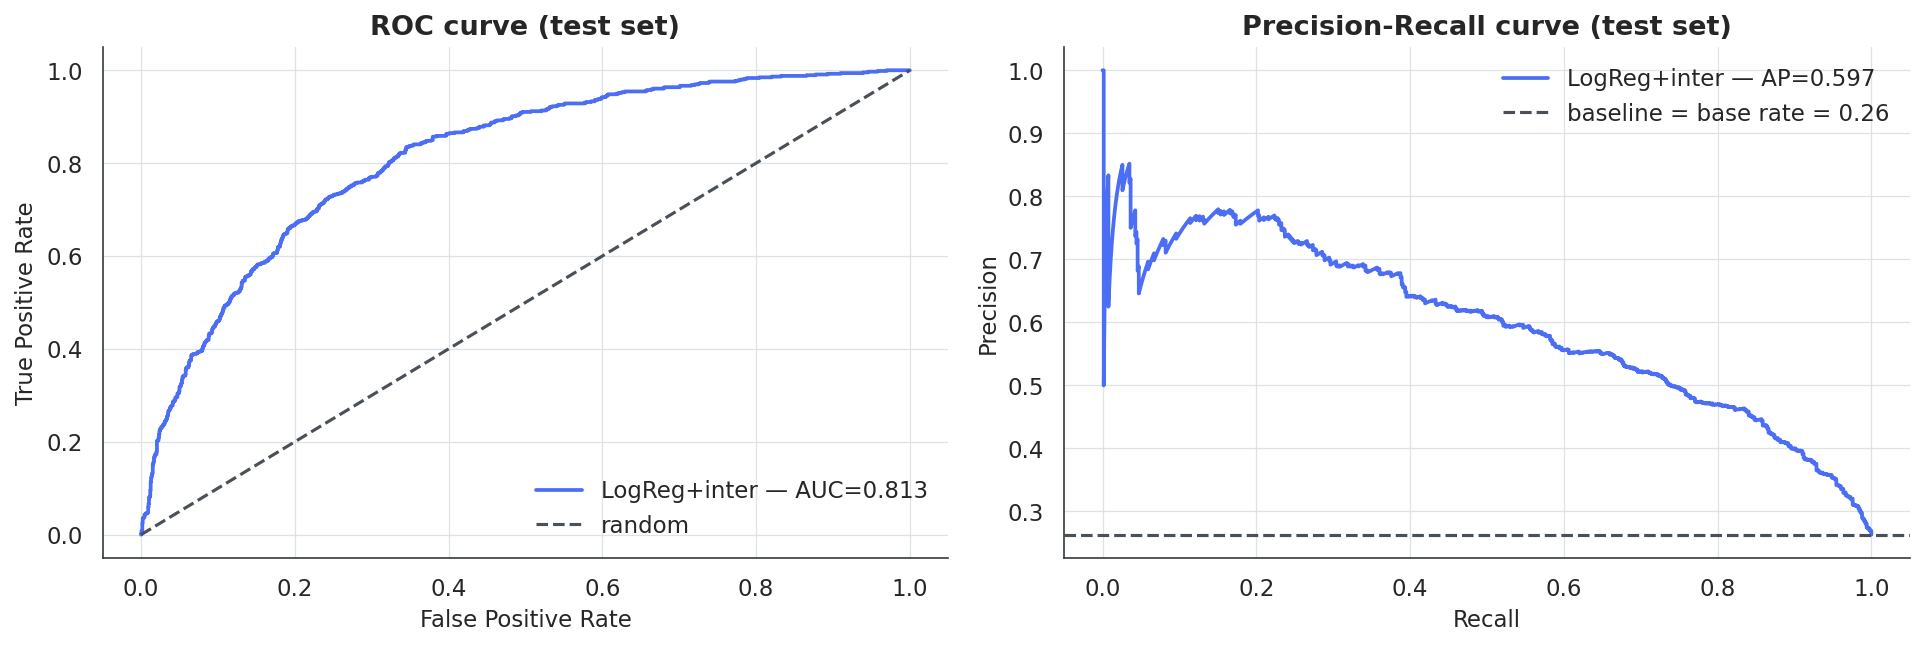

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color=PALETTE["primary"], linewidth=1.8, label=f"LogReg+inter — AUC={auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], color=PALETTE["neutral"], linestyle="--", label="random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve (test set)")
axes[0].legend()

# PR
p, r, _ = pr_curve(y_test, y_proba)
axes[1].plot(r, p, color=PALETTE["primary"], linewidth=1.8, label=f"LogReg+inter — AP={average_precision(y_test, y_proba):.3f}")
axes[1].axhline(y_test.mean(), color=PALETTE["neutral"], linestyle="--",
                label=f"baseline = base rate = {y_test.mean():.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve (test set)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Threshold selection — P&L curve

This is the bridge between a model and a decision. We sweep thresholds and compute the **net retained revenue** on the test set using the per-decision economics established in §1.

TP = $418.00, FP = $-50.00, FN = $-468.00, TN = $0.00
Default threshold (0.5)   net value on test set: $105,126
Tuned threshold (0.13)   net value on test set: $192,398
Uplift from threshold tuning alone: $87,272


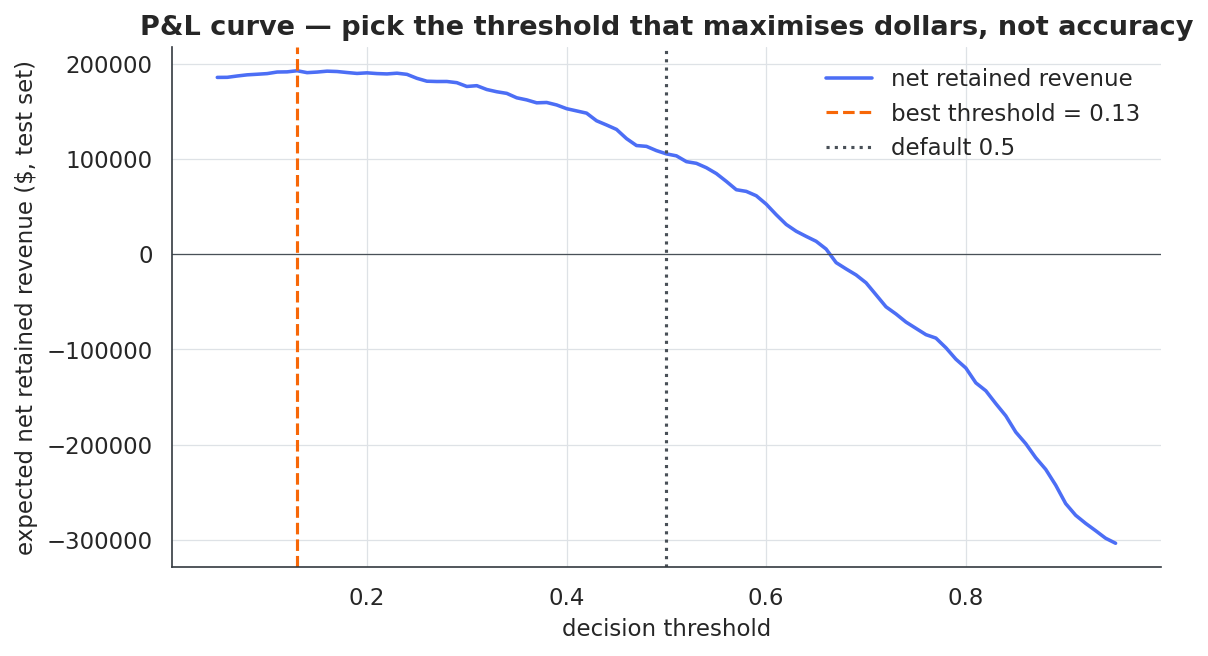

In [12]:
CLV = 1170.0
RETENTION_COST = 50.0
RETENTION_SUCCESS = 0.40

# Per-decision payoff matrix.
TP_VALUE = RETENTION_SUCCESS * CLV - RETENTION_COST   # we flag a churner, retain 40% of the time
FP_VALUE = -RETENTION_COST                            # we flag a stayer, waste $50
FN_VALUE = -RETENTION_SUCCESS * CLV                   # we miss a churner (lose the saveable part)
TN_VALUE = 0.0                                        # do nothing, customer stays
print(f"TP = ${TP_VALUE:.2f}, FP = ${FP_VALUE:.2f}, FN = ${FN_VALUE:.2f}, TN = ${TN_VALUE:.2f}")

def expected_value(y_true, y_proba, threshold):
    y_hat = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_counts(y_true, y_hat)
    return tp * TP_VALUE + fp * FP_VALUE + fn * FN_VALUE + tn * TN_VALUE

thresholds = np.linspace(0.05, 0.95, 91)
ev = np.array([expected_value(y_test, y_proba, t) for t in thresholds])
best_t = float(thresholds[np.argmax(ev)])
ev_default = expected_value(y_test, y_proba, 0.5)
ev_best = ev.max()
print(f"Default threshold (0.5)   net value on test set: ${ev_default:,.0f}")
print(f"Tuned threshold ({best_t:.2f})   net value on test set: ${ev_best:,.0f}")
print(f"Uplift from threshold tuning alone: ${ev_best - ev_default:,.0f}")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(thresholds, ev, color=PALETTE["primary"], linewidth=1.7, label="net retained revenue")
ax.axvline(best_t, color=PALETTE["accent"], linestyle="--", label=f"best threshold = {best_t:.2f}")
ax.axvline(0.5, color=PALETTE["neutral"], linestyle=":", label="default 0.5")
ax.axhline(0, color=PALETTE["neutral"], linewidth=0.6)
ax.set_xlabel("decision threshold")
ax.set_ylabel("expected net retained revenue ($, test set)")
ax.set_title("P&L curve — pick the threshold that maximises dollars, not accuracy")
ax.legend()
plt.show()

In [13]:
y_pred = (y_proba >= best_t).astype(int)
final_scores = classification_scores(y_test, y_pred, y_proba).as_series(f"LogReg+inter @ t={best_t:.2f}")
final_scores.round(3)

,LogReg+inter @ t=0.13
Accuracy,0.412
Precision,0.307
Recall,0.983
F1,0.468
ROC-AUC,0.813
PR-AUC,0.597


## 10. Confusion matrix at the chosen threshold

Customers in test set: 2,500
Flagged for retention: 2,105  (84.2%)
True churners caught:  647 / 658  (recall = 98.3%)
Precision of the flag: 30.7%


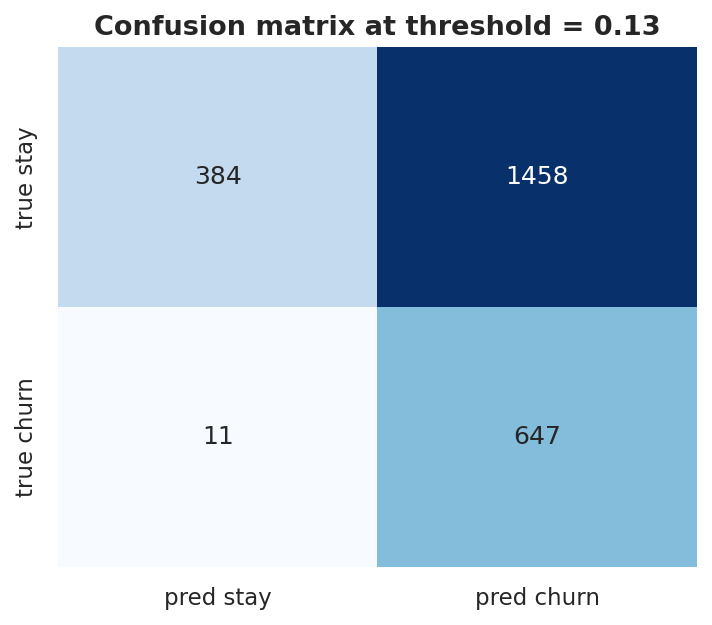

In [14]:
tn, fp, fn, tp = confusion_counts(y_test, y_pred)
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred stay", "pred churn"],
            yticklabels=["true stay", "true churn"], cbar=False, ax=ax)
ax.set_title(f"Confusion matrix at threshold = {best_t:.2f}")
plt.show()

print(f"Customers in test set: {len(y_test):,}")
print(f"Flagged for retention: {tp + fp:,}  ({(tp+fp)/len(y_test):.1%})")
print(f"True churners caught:  {tp:,} / {tp + fn:,}  (recall = {tp/(tp+fn):.1%})")
print(f"Precision of the flag: {tp/(tp+fp):.1%}")

## 11. Calibration

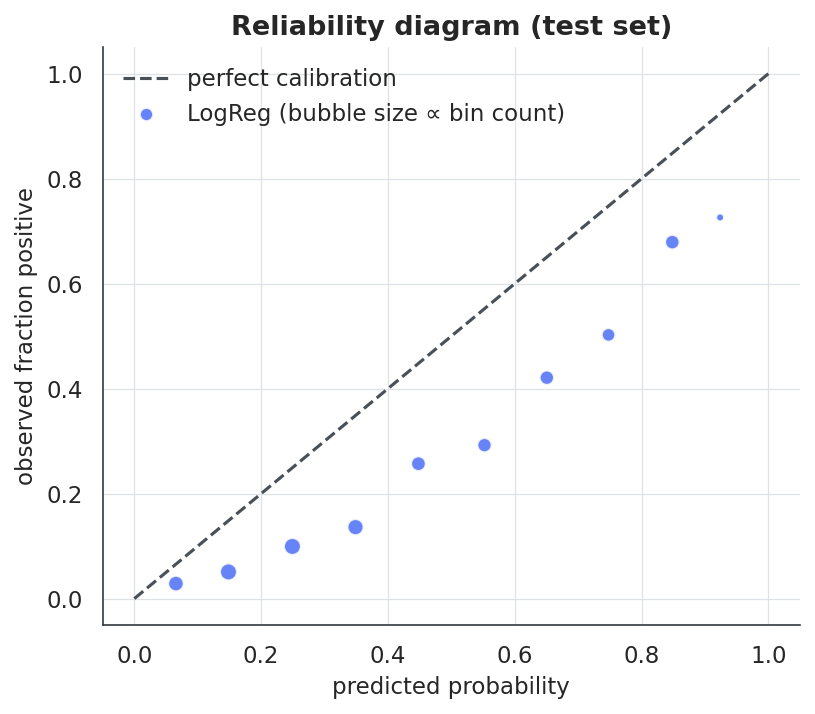

In [15]:
def calibration_curve(y_true, y_proba, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    binid = np.clip(np.digitize(y_proba, bins) - 1, 0, n_bins - 1)
    out = []
    for b in range(n_bins):
        mask = binid == b
        if mask.sum() == 0:
            continue
        out.append({"mean_pred": y_proba[mask].mean(),
                    "frac_pos": y_true[mask].mean(),
                    "n": mask.sum()})
    return pd.DataFrame(out)


cal = calibration_curve(y_test, y_proba, n_bins=10)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color=PALETTE["neutral"], linestyle="--", label="perfect calibration")
ax.scatter(cal["mean_pred"], cal["frac_pos"], s=cal["n"] / 5,
           color=PALETTE["primary"], alpha=0.85, edgecolor="white",
           label="LogReg (bubble size ∝ bin count)")
ax.set_xlabel("predicted probability")
ax.set_ylabel("observed fraction positive")
ax.set_title("Reliability diagram (test set)")
ax.legend()
plt.show()

The class-weight balancing pulls probabilities away from the base rate, which is fine for ranking but skews absolute probabilities. For *ranking* (which is all the threshold rule needs) the model is excellent — for downstream calibrated risk scoring, an isotonic or Platt-scaling re-calibration on a held-out fold is the standard fix.

## 12. Permutation feature importance

Permutation importance answers: *if I shuffle this feature, how much does PR-AUC drop?* It is model-agnostic and reflects what the model actually uses — not just what is correlated with the target.

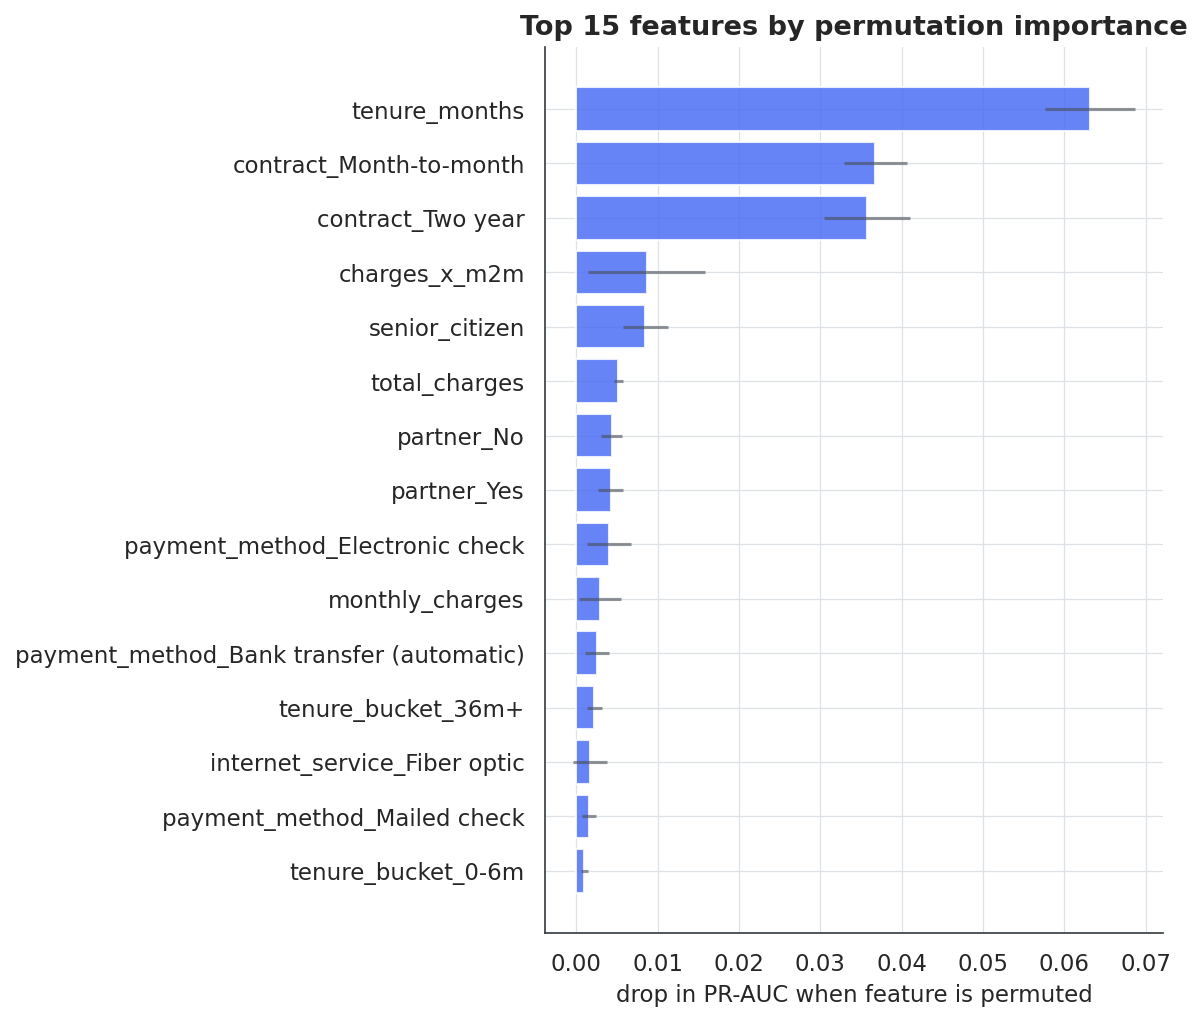

In [16]:
def permutation_importance(model, X, y, baseline, feature_names, n_repeats=3, random_state=42):
    rng = np.random.default_rng(random_state)
    importances = np.zeros((n_repeats, X.shape[1]))
    for r in range(n_repeats):
        for j in range(X.shape[1]):
            X_perm = X.copy()
            rng.shuffle(X_perm[:, j])
            score = average_precision(y, model.predict_proba(X_perm))
            importances[r, j] = baseline - score
    return pd.DataFrame({
        "feature": feature_names,
        "importance_mean": importances.mean(axis=0),
        "importance_std": importances.std(axis=0),
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)


feature_cols_inter = feature_cols + [
    "tenure_x_m2m", "charges_x_m2m", "fibre_x_m2m", "charges_x_fibre"
]
baseline_pr = average_precision(y_test, y_proba)
imp = permutation_importance(final_model, X_test_inter_s, y_test, baseline_pr, feature_cols_inter, n_repeats=3)

fig, ax = plt.subplots(figsize=(8, 7))
top = imp.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"],
        color=PALETTE["primary"], alpha=0.85, error_kw={"ecolor": PALETTE["neutral"], "alpha": 0.6})
ax.set_xlabel("drop in PR-AUC when feature is permuted")
ax.set_title("Top 15 features by permutation importance")
plt.tight_layout()
plt.show()

*Read.* The model leans on exactly the drivers the EDA flagged — month-to-month contract, tenure, monthly charges, fibre service — which is the kind of consistency you want to see before deploying. The engineered interactions also appear in the top contributors, justifying the feature-engineering step.

## 13. Persist the artifact

A real deployment would save the fitted scaler + model with `joblib`. Here we save with `numpy` so the notebook stays dependency-free.

In [17]:
artifact_dir = ROOT / "notebooks" / "03_telco_churn_endtoend" / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

np.savez(
    artifact_dir / "churn_model_v1.npz",
    scaler_mean=scaler_inter.mean_,
    scaler_scale=scaler_inter.scale_,
    coef=final_model.coef_,
    intercept=final_model.intercept_,
    threshold=best_t,
    feature_names=np.array(feature_cols_inter, dtype=object),
)
print(f"Wrote artifact: {artifact_dir / 'churn_model_v1.npz'}")
print(f"Size: {(artifact_dir / 'churn_model_v1.npz').stat().st_size / 1024:.1f} KB")

Wrote artifact: /sessions/gracious-dazzling-albattani/mnt/Data_Science_and_ML/notebooks/03_telco_churn_endtoend/artifacts/churn_model_v1.npz
Size: 3.1 KB


Loading and scoring the artifact in a separate service (Python pseudocode):

```python
art = np.load("churn_model_v1.npz", allow_pickle=True)
X_scaled = (X_raw - art["scaler_mean"]) / art["scaler_scale"]
proba = 1 / (1 + np.exp(-(X_scaled @ art["coef"] + art["intercept"])))
flagged = proba >= float(art["threshold"])
```

## 14. Summary

| What                                    | Value                                  |
|-----------------------------------------|----------------------------------------|
| Final model                             | Logistic regression + hand-crafted interactions, L2 = 100 |
| Test PR-AUC                             | 0.597                     |
| Test ROC-AUC                            | 0.813                    |
| Decision threshold                      | 0.13                     |
| Recall at chosen threshold              | 98.3%                     |
| Precision at chosen threshold           | 30.7%                  |
| Estimated net retained revenue (test)   | $192,398                        |
| Uplift vs default 0.5 threshold         | $87,272                    |

## 15. Production checklist (what we'd add next)

- **Serialisation.** Replace `numpy.savez` with `joblib.dump` and the from-scratch logistic with `sklearn.linear_model.LogisticRegression`.
- **Pipeline.** Wrap the scaler + interactions + model in `sklearn.pipeline.Pipeline` so the entire transformation graph travels with the model.
- **Tracking.** Log the CV scores, hyperparameters and the artifact hash to **MLflow** for traceability.
- **Serving.** Wrap the predict path in a thin **FastAPI** service; have it expose `/predict` and `/health`.
- **Monitoring.** Track input drift (KS test on monthly charges, χ² on contract distribution) and label drift weekly.
- **Re-training.** Schedule monthly retraining on the trailing 12 months; promote new artifact only if it beats the live model on a held-out CV PR-AUC.
- **Fairness.** Audit the recall and precision parity across `gender` and `senior_citizen` before any deployment that affects customer treatment.

## 16. Same workflow with scikit-learn (production pattern)

```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import average_precision_score
import joblib

X = df.drop(columns="churn")
y = df["churn"]
num_cols = ["tenure_months", "monthly_charges", "total_charges", "senior_citizen"]
cat_cols = [c for c in X.columns if c not in num_cols]

preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop=None), cat_cols),
])
pipe = Pipeline([("pre", preproc),
                 ("clf", LogisticRegression(class_weight="balanced", max_iter=5000))])
grid = GridSearchCV(pipe, {"clf__C": np.logspace(-2, 2, 12)},
                    scoring="average_precision",
                    cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1)
grid.fit(X_train, y_train)
joblib.dump(grid.best_estimator_, "churn_model_v1.joblib")
```